# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# 2. Load Dataset

In [2]:
data = pd.read_csv("housing.csv", header = None, delim_whitespace = True)
data

C:\Users\Kalluru Prem\AppData\Local\Temp\ipykernel_22264\2129156624.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("housing.csv", header = None, delim_whitespace = True)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [3]:
data.columns = [
    'crime rate', 'zone land', 'proportion non-retail land', 'charles river',
    'nitric oxide', 'average rooms', 'age', 'distance to EC',
    'radial highways', 'tax rate', 'pupil teacher ratio',
    'proportion of blacks', 'low status', 'median value OO'
]

In [4]:
print(data.head())

   crime rate  zone land  proportion non-retail land  charles river  \
0     0.00632       18.0                        2.31              0   
1     0.02731        0.0                        7.07              0   
2     0.02729        0.0                        7.07              0   
3     0.03237        0.0                        2.18              0   
4     0.06905        0.0                        2.18              0   

   nitric oxide  average rooms   age  distance to EC  radial highways  \
0         0.538          6.575  65.2          4.0900                1   
1         0.469          6.421  78.9          4.9671                2   
2         0.469          7.185  61.1          4.9671                2   
3         0.458          6.998  45.8          6.0622                3   
4         0.458          7.147  54.2          6.0622                3   

   tax rate  pupil teacher ratio  proportion of blacks  low status  \
0     296.0                 15.3                396.90        4.

In [5]:
print("\nInfo:\n")
print(data.info())
print("\nShape:", data.shape)


Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   crime rate                  506 non-null    float64
 1   zone land                   506 non-null    float64
 2   proportion non-retail land  506 non-null    float64
 3   charles river               506 non-null    int64  
 4   nitric oxide                506 non-null    float64
 5   average rooms               506 non-null    float64
 6   age                         506 non-null    float64
 7   distance to EC              506 non-null    float64
 8   radial highways             506 non-null    int64  
 9   tax rate                    506 non-null    float64
 10  pupil teacher ratio         506 non-null    float64
 11  proportion of blacks        506 non-null    float64
 12  low status                  506 non-null    float64
 13  median value OO            

# 3. Exploratory Data Analysis (EDA)

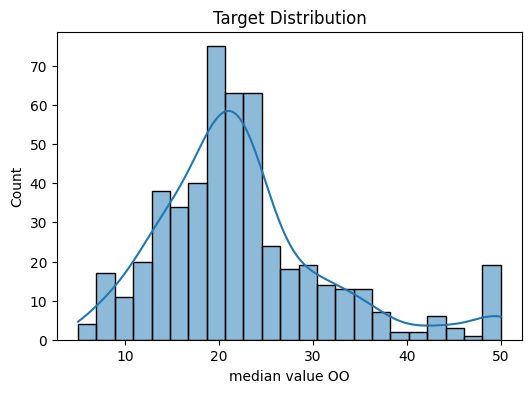

In [31]:
# Target distribution
plt.figure(figsize = (6,4))
sns.histplot(data['median value OO'], kde=True)
plt.title("Target Distribution")
plt.show()

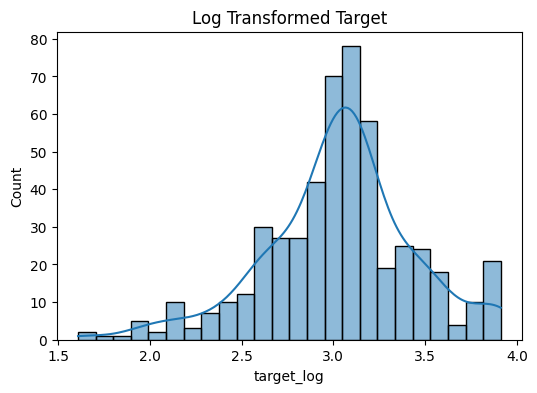

In [30]:
# Log transform
data['target_log'] = np.log(data['median value OO'])

plt.figure(figsize = (6,4))
sns.histplot(data['target_log'], kde = True)
plt.title("Log Transformed Target")
plt.show()

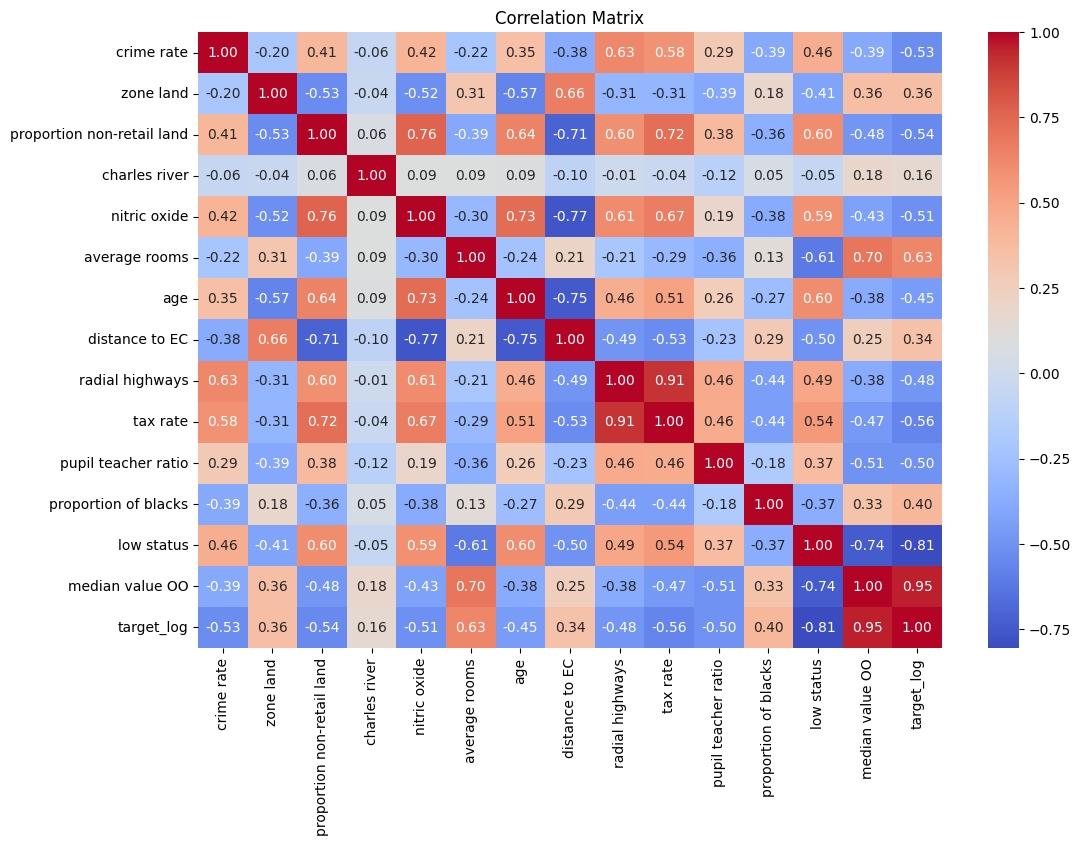

In [29]:
# Correlation heatmap
plt.figure(figsize = (12,8))
sns.heatmap(data.corr(), annot = True, fmt = ".2f", cmap = 'coolwarm')
plt.title("Correlation Matrix")
plt.show()

# 4. Features & Target

In [26]:
X = data.drop(['median value OO', 'target_log'], axis = 1)
y = data['target_log']   # using log target

# 5. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# 6. Scaling

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Model Training & Comparison

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state = 42),
    "SVR": SVR()
}

In [13]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [14]:
results_df = pd.DataFrame(results)

print("\nModel Performance:\n", results_df)


Model Performance:
                Model       MAE      RMSE        R2
0  Linear Regression  0.132620  0.198877  0.746272
1      Random Forest  0.107738  0.159010  0.837800
2                SVR  0.105981  0.160479  0.834790


# 8. Model Comparison Plot

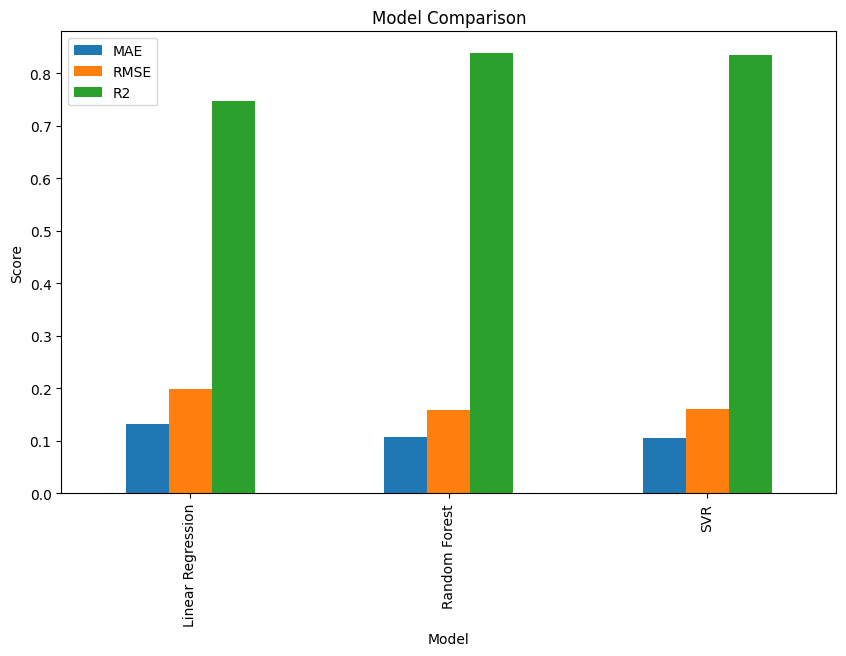

In [25]:
results_df.set_index("Model")[["MAE", "RMSE", "R2"]].plot(
    kind='bar', figsize = (10,6)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.show()

# 9. Best Model Selection

In [16]:
best_model_name = results_df.loc[results_df['R2'].idxmax(), 'Model']
print("\nBest Model:", best_model_name)


Best Model: Random Forest


In [17]:
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)

y_pred_best = best_model.predict(X_test_scaled)

# 10. Predicted vs Actual Plot

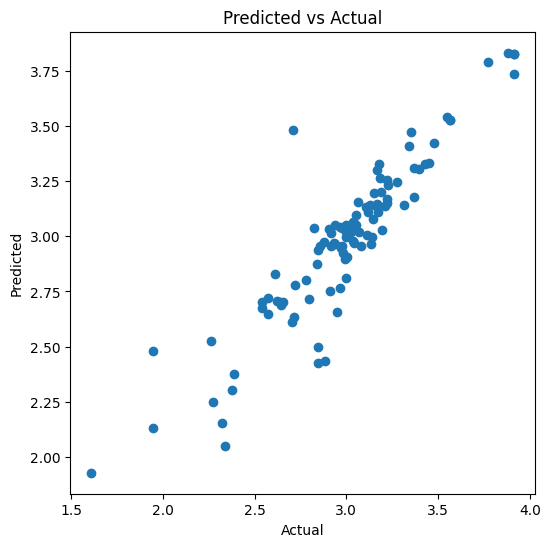

In [18]:
plt.figure(figsize = (6,6))
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

# 11. Residual Plot

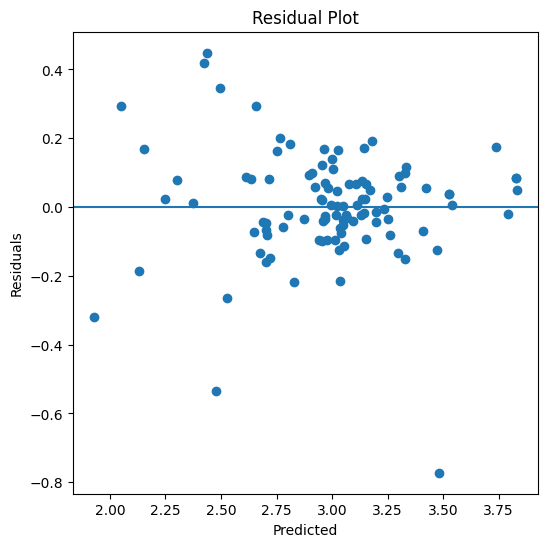

In [19]:

residuals = y_test - y_pred_best

plt.figure(figsize = (6,6))
plt.scatter(y_pred_best, residuals)
plt.axhline(y = 0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



# 12. Cross Validation

In [20]:
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_results[name] = scores

cv_df = pd.DataFrame(cv_results)

print("\nCross Validation Scores:\n", cv_df)


Cross Validation Scores:
    Linear Regression  Random Forest       SVR
0           0.700243       0.675438  0.140168
1           0.677542       0.741844  0.148569
2           0.619402       0.715246 -0.469709
3           0.488270       0.678997  0.213973
4           0.519878       0.480908 -0.685827


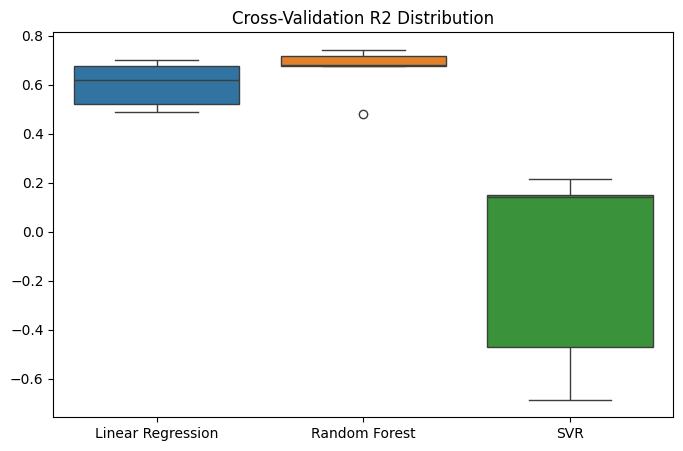

In [23]:
# Boxplot
plt.figure(figsize = (8,5))
sns.boxplot(data = cv_df)
plt.title("Cross-Validation R2 Distribution")
plt.show()

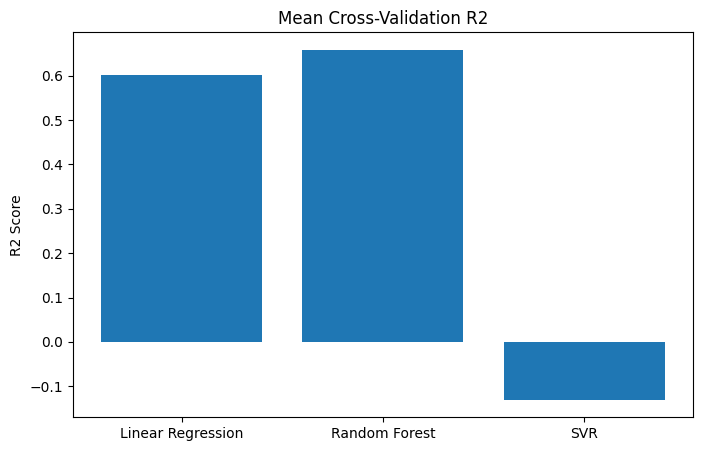

In [24]:
# Mean CV plot
plt.figure(figsize = (8,5))
plt.bar(cv_df.columns, cv_df.mean())
plt.title("Mean Cross-Validation R2")
plt.ylabel("R2 Score")
plt.show()